### Importar las librerías necesarias

In [1]:
# Importamos lo necesario
import os
import numpy as np
import cv2

from matplotlib import pyplot as plt
import matplotlib

from time import time
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import MinMaxScaler

### Cargar el dataset

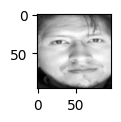

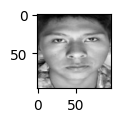

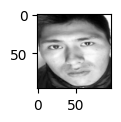

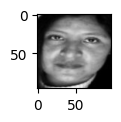

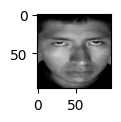

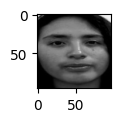

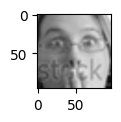

Dataset info:
# samples: 13616
# features: 9216
# classes: 7
classes ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [2]:
# carpeta con la imagenes
folder = r"C:\Users\mario\Downloads\datasetpreprocesado"    # CAMBIAR LA RUTA

# CONFIGURACION
# Limita cuántas imágenes cargas por clase
max_per_class = 3000
# tamaño estandar para las imágenes
TARGET_SIZE = (96, 96)
# extensiones permitidas
valid_extensions = ('.jpg', '.jpeg', '.png')

# Inicializa estructuras de datos y sus correpondientes etiquetas
X = []
Y = []
# muestras por clase
nperclass = []
# Etiqueta de cada clase (nombre de la subcarpeta)
classlabels = []

# Valor de resolución por defecto de matplotlib
dpi = matplotlib.rcParams['figure.dpi']

# Asume que en la ruta indicada hay una subcarpeta por clase
for class_index, class_name in enumerate(sorted(os.listdir(folder))):
    # Inicialmente esta clase no tiene muestras
    nsamples = 0

    # Compone la ruta
    class_folder = os.path.join(folder, class_name)

    if not os.path.isdir(class_folder):
        continue

    for file_name in os.listdir(class_folder):
        if nsamples >= max_per_class:
            break

        # Acepta jpg, jpeg y png
        if file_name.lower().endswith(valid_extensions):
            file_path = os.path.join(class_folder, file_name)
            
            if not os.path.exists(file_path):
                print(f"No existe: {file_path}")
                continue

            # Lee la imagen
            image = cv2.imread(file_path)

            if image is None:
                print(f"No se pudo leer: {file_path}")
                continue

            image = cv2.resize(image, TARGET_SIZE)

            # Extrae tamaños
            height, width, depth = image.shape
            # Convierte a grises
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            # Añade a X, previa conversión en vector
            X.append(gray.reshape(height*width))
            # Añade etiqueta numérica de la muestra
            Y.append(class_index)
            # Muestra primera imagen de la clase
            if nsamples == 0:
                figsize = width / float(dpi), height / float(dpi)

                plt.figure(figsize=figsize)
                plt.imshow(gray, cmap='gray', vmin=0, vmax=255)
                plt.show()
  
            #Incrementa el número de muestras
            nsamples += 1
    nperclass.append(nsamples)
    classlabels.append(class_name)
    
#Convierte a numpy array X e Y
X = np.array(X, dtype='float32')
Y = np.array(Y, dtype='float64')

# Obtiene número de muestras y características
n_samples, n_features = X.shape
# Obtiene nombres de las clases
class_names = np.array(classlabels)
n_classes = class_names.shape[0]

print("Dataset info:")
print("# samples: %d" % n_samples)
print("# features: %d" % n_features)
print("# classes: %d" % n_classes)
print("classes %s" % classlabels)


### Separar en entrenamiento y test

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42)

print("# samples in training set %d" % X_train.shape[0])
print("# samples in test set %d" % X_test.shape[0])

# samples in training set 9531
# samples in test set 4085


### Aplicar PCA (95% varianza)

In [4]:
print("PCA computation for .95 of the variance from %d faces..." % X_train.shape[0])
t0 = time()
pca_95 = PCA(0.95).fit(X_train)
print("done in %0.3fs" % (time() - t0))
print("%d components selected" % pca_95.n_components_)

# Transforma los datos
X_train_pca_95 = pca_95.transform(X_train)
X_test_pca_95 = pca_95.transform(X_test)


PCA computation for .95 of the variance from 9531 faces...
done in 210.297s
138 components selected


### Normalizar los datos

In [5]:
print("Normalization...")
scaler = MinMaxScaler()
train_X = scaler.fit_transform(X_train_pca_95)
test_X = scaler.transform(X_test_pca_95)

Normalization...


### Entrenar SVM

In [6]:
print("SVM training...")
t0 = time()
parameters = {'C': [1e3, 5e3, 1e4, 5e4, 1e5],
              'gamma': [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.1],}

clf_pca_95 = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced'), 
    parameters, 
    cv=5,
    n_jobs=-1
)
clf_pca_95 = clf_pca_95.fit(train_X, y_train)
print("done in %0.3fs" % (time() - t0))
print("Best estimator found by grid search:")
print(clf_pca_95.best_estimator_)

SVM training...
done in 1226.212s
Best estimator found by grid search:
SVC(C=10000.0, class_weight='balanced', gamma=0.01)


### Evaluar el modelo

In [7]:
print("Predicting")
t0 = time()
y_pred = clf_pca_95.predict(test_X)
print("done in %0.3fs" % (time() - t0))

print("\nMetrics")
print(classification_report(y_test, y_pred, target_names=class_names))
print("Precision:  %0.3f, Recall:  %0.3f" % ( precision_score(y_test, y_pred, average="weighted"),recall_score(y_test, y_pred, average="weighted"))) 
print("Confusion matrix")
print(confusion_matrix(y_test, y_pred, labels=range(n_classes)))

Predicting
done in 5.119s

Metrics
              precision    recall  f1-score   support

       angry       0.63      0.70      0.67       657
     disgust       0.80      0.68      0.73       189
        fear       0.68      0.63      0.65       495
       happy       0.72      0.63      0.67       870
     neutral       0.74      0.82      0.78       902
         sad       0.65      0.64      0.64       521
    surprise       0.83      0.85      0.84       451

    accuracy                           0.71      4085
   macro avg       0.72      0.71      0.71      4085
weighted avg       0.71      0.71      0.71      4085

Precision:  0.713, Recall:  0.712
Confusion matrix
[[462  13  39  38  49  51   5]
 [ 24 128   4  16   3   9   5]
 [ 72   7 310  22  11  52  21]
 [ 61   4  29 548 166  34  28]
 [ 34   1  16  88 743  18   2]
 [ 68   6  34  32  29 335  17]
 [ 10   1  23  13   1  20 383]]


### Detector de emociones por cámara (entrenar el modelo antes de ejecutar)

In [9]:
#asumo que el modelo (clf_pca_95, pca_95, scaler) ya está entrenado
from mtcnn import MTCNN

# Se inicializa el detector de caras
detector = MTCNN()

# Capturamos el video de la camara
cap = cv2.VideoCapture(0)
TARGET_SIZE = (96, 96)  # El modelo se entrenó en este tamaño

while True:
    ret, frame = cap.read()
    if not ret:
        print("Error con el frame.")
        break

    # buscamos la cara en el frame
    faces = detector.detect_faces(frame)

    if len(faces) > 0:
        #toma la primera cara
        face = faces[0]

        x, y, w, h = face["box"]

        # procesamos la cara para dejarla como quiere el detector
        face_roi = cv2.cvtColor(frame[y:y+h, x:x+w], cv2.COLOR_BGR2GRAY)        
        
        # Mejora de contraste
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        face_roi = clahe.apply(face_roi)
        # Normalización adicional
        face_roi = cv2.normalize(face_roi, None, 0, 255, cv2.NORM_MINMAX)

        face_resized = cv2.resize(face_roi, TARGET_SIZE)

        # PCA → Scaler → SVM
        face_vector = face_resized.reshape(1, -1).astype("float32")
        face_pca = pca_95.transform(face_vector)
        face_normalized = scaler.transform(face_pca)
        emotion_pred = clf_pca_95.predict(face_normalized)[0]
        emotion_name = class_names[int(emotion_pred)]

        # dibujo el recuadro
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(frame, emotion_name, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
    
    cv2.imshow("Detector de emociones", frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

### Thermal Vision Filter

In [5]:
import cv2
import numpy as np
from mtcnn import MTCNN

# Inicializamos el detector de caras MTCNN
detector = MTCNN()

# Inicializamos captura de video
video = cv2.VideoCapture(0)

# Definimos la lista de colormaps disponibles
colorMapMethods = [
    cv2.COLORMAP_JET, 
    cv2.COLORMAP_HOT, 
    cv2.COLORMAP_OCEAN, 
    cv2.COLORMAP_RAINBOW, 
    cv2.COLORMAP_DEEPGREEN
]

# Declaramos el índice del colormap actual
i = 0  

# Declaramos un flag para el escaneo
scanning = False  

# Declaramos la variable de progreso del escaneo ( de 0 a 1)
scan_progress = 0  

# Declaramos la velocidad del efecto de escaneo
scan_speed = 0.05  

# Declaramos variable para detectar la primera aparición de la cara
first_detection = True 

# Mostramos los controles en la terminal
print("Controles:")
print("  D - Cambiar colormap (inicia escaneo)")
print("  Q - Salir")
print("\nIniciando...")
print("Esperando detección de rostro...")

# Empezamos el bucle de procesamiento de video
while True:
    
    # Capturamos un frame
    ret, frame = video.read()

    # Si no se captura correctamente, salimos del bucle
    if not ret:
        print("Error al capturar frame")
        break

    # Detectamos caras en el frame
    detections = detector.detect_faces(frame)
    
    # Creamos máscara negra del mismo tamaño que el frame
    mask = np.zeros(frame.shape[:2], dtype=np.uint8)

    # Declaramos una variable para guardar la región facial (bounding box)
    face_region = None
    
    # Si hay caras detectadas, procesamos la primera
    if len(detections) > 0:

        # Guardamos la primera detección
        det = detections[0]  
        x, y, width, height = det['box']
        
        # Si es la primera detección, iniciamos el escaneo
        if first_detection:
            scanning = True
            scan_progress = 0
            first_detection = False
    
        # Guardamos la región facial para el escaneo
        face_region = (x, y, width, height)
        
        # Expandimos la región del rostro para disminuir un poco el error de detección
        padding = int(width * 0.1)  # 10% extra alrededor
        x1 = max(0, x - padding)
        y1 = max(0, y - padding)
        x2 = min(frame.shape[1], x + width + padding)
        y2 = min(frame.shape[0], y + height + padding)
        
        # Calculamos el centro y los ejes de la elipse que cubrirá la cara
        center = ((x1 + x2) // 2, (y1 + y2) // 2)
        axes = ((x2 - x1) // 2, (y2 - y1) // 2)
        
        # La dibujamos en la máscara
        cv2.ellipse(mask, center, axes, 0, 0, 360, 255, -1)
    
    # Aplicamos Gaussian Blur para suavizar los bordes de la máscara
    mask = cv2.GaussianBlur(mask, (51, 51), 0)
    
    # Normalizamos máscara (convertir de 0-255 a 0.0-1.0)
    mask = mask / 255.0

    # Suavizamos frame original
    frameSuavizado = cv2.GaussianBlur(frame, (5, 5), 0)
    
    # Convertimos el frame a escala de grises
    frameGray = cv2.cvtColor(frameSuavizado, cv2.COLOR_BGR2GRAY)
    
    # Convertimos a formato térmico usando el colormap actual
    colorMap = cv2.applyColorMap(frameGray, colorMapMethods[i])

    # Convertir máscara a 3 canales (BGR)
    mask_3ch = np.stack([mask] * 3, axis=2)
    
    # Si estamos en modo escaneo
    if scanning and face_region is not None:

        # Incrementamos el progreso del escaneo
        scan_progress += scan_speed
        
        # Si llegamos al final, terminar escaneo
        if scan_progress >= 1.0:
            scan_progress = 1.0
            scanning = False
        
        # Extraemos coordenadas de la cara
        fx, fy, fw, fh = face_region
        
        # Calculamos hasta dónde ha llegado el escaneo
        scan_y = fy + int(fh * scan_progress)

        # Creamos máscara de escaneo (solo mostrar efecto térmico hasta scan_y)
        scan_mask = np.zeros(frame.shape[:2], dtype=np.float32)
        scan_mask[fy:scan_y, fx:fx+fw] = 1.0  

        # Suavizamos bordes de la máscara de escaneo
        scan_mask = cv2.GaussianBlur(scan_mask, (15, 15), 0)
        scan_mask_3ch = np.stack([scan_mask] * 3, axis=2)
        
        # Combinamos máscara facial con máscara de escaneo
        combined_mask = mask_3ch * scan_mask_3ch
        
        # Aplicamos efecto térmico progresivamente
        resultado = (colorMap * combined_mask + frame * (1 - combined_mask)).astype(np.uint8)
        
        # Dibujamos la Línea de escaneo
        cv2.line(resultado, (fx, scan_y), (fx + fw, scan_y), (255, 255, 255), 3)

        # Dibujamos el texto de escaneo
        cv2.putText(resultado, "SCANNING...", (fx, fy - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
        
        # Dibujamos la barra de progreso
        progress_width = int(fw * scan_progress)
        cv2.rectangle(resultado, (fx, fy - 25), (fx + progress_width, fy - 20), (0, 255, 255), -1)
        cv2.rectangle(resultado, (fx, fy - 25), (fx + fw, fy - 20), (0, 255, 255), 2)
    
    else:
        # No hay escaneo: aplicar efecto térmico en toda la máscara
        resultado = (colorMap * mask_3ch + frame * (1 - mask_3ch)).astype(np.uint8)
    
    # Mostramos el resultado
    cv2.imshow('Thermal Vision', resultado)
    
    # Capturamos la tecla presionada
    key = cv2.waitKey(1) & 0xFF
    
    # Cambiar colormap con 'd' e INICIAR ESCANEO
    if key == ord('d'):
        i = (i + 1) % len(colorMapMethods)
        scanning = True  # Activar escaneo
        scan_progress = 0  # Reiniciar progreso
        print(f"Colormap cambiado a: {i} - Iniciando escaneo...")
    
    # Salir con 'q'
    if key == ord('q'):
        break

# Liberar recursos
video.release()
cv2.destroyAllWindows()
print("Programa finalizado")

Controles:
  D - Cambiar colormap (inicia escaneo)
  Q - Salir

Iniciando...
Esperando detección de rostro...
Programa finalizado
